In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

## Load Experiment Results

In [2]:
# Load merged experiment results
df_merged = pd.read_csv("../../results_shared/pipeline_result/merged_experiment_results.csv")

print(f"Experiment results shape: {df_merged.shape}")
df_merged.head(2)

Experiment results shape: (698, 21)


,dataset,variate,num_variates,model,eval_metrics/MAR[0.5],eval_metrics/MBR[0.5],eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],...,eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,dataset_slug,freq,term,dataset_name
0,bitbrains_fast_storage/5t/short,MULTI,2,Chronos2-GiftEval,1.096216,0.684252,3.787301e+06,3.787301e+06,324.170261,0.651166,...,0.737697,13.319339,1946.098956,3.077105,0.512567,0.398537,bitbrains_fast_storage_5T__short,5t,short,bitbrains_fast_storage
1,bitbrains_fast_storage/h/short,MULTI,2,Chronos2-GiftEval,1.252003,0.743833,1.030553e+07,1.030553e+07,768.257435,0.991605,...,0.591123,19.141390,3210.222383,4.606590,1.102430,0.805784,bitbrains_fast_storage_H__short,h,short,bitbrains_fast_storage


## Load Official GIFT-EVAL Results

In [3]:
# Load official GIFT-EVAL results
official_chronos2 = pd.read_csv("../../results_shared/02_gift-eval_official/chronos2.csv")
official_moirai = pd.read_csv("../../results_shared/02_gift-eval_official/moirai.csv")
official_toto = pd.read_csv("../../results_shared/02_gift-eval_official/toto.csv")

# Add model column to identify which model each result belongs to
official_chronos2['model'] = 'Chronos2-Official'
official_moirai['model'] = 'Moirai-Official'
official_toto['model'] = 'ToTo-Official'

# Combine all official results
df_official = pd.concat([official_chronos2, official_moirai, official_toto], ignore_index=True)
df_official['dataset'] = df_official['dataset'].apply(lambda x: x.lower())
print("Official results shape:", df_official.shape)
print("\nOfficial results columns:")
print(df_official.columns.tolist())
df_official.head(2)

Official results shape: (291, 16)

Official results columns:
['dataset', 'model', 'eval_metrics/MSE[mean]', 'eval_metrics/MSE[0.5]', 'eval_metrics/MAE[0.5]', 'eval_metrics/MASE[0.5]', 'eval_metrics/MAPE[0.5]', 'eval_metrics/sMAPE[0.5]', 'eval_metrics/MSIS', 'eval_metrics/RMSE[mean]', 'eval_metrics/NRMSE[mean]', 'eval_metrics/ND[0.5]', 'eval_metrics/mean_weighted_sum_quantile_loss', 'domain', 'num_variates', 'eval_metrics/MAAPE[0.5]']


,dataset,model,eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,domain,num_variates,eval_metrics/MAAPE[0.5]
0,bitbrains_fast_storage/5t/long,Chronos2-Official,4.145797e+06,4.145797e+06,357.973674,0.871200,3.782841,0.836076,15.432955,2036.123152,5.380865,0.946017,0.702606,Web/CloudOps,2.0,NaN
1,bitbrains_fast_storage/5t/medium,Chronos2-Official,2.854814e+06,2.854814e+06,267.825984,0.958849,3.451545,0.818901,20.728725,1689.619440,5.133531,0.813729,0.623346,Web/CloudOps,2.0,NaN


## Load Failed Datasets

In [4]:
# Load failed datasets from experiments
failed_files = {
    'Chronos2-multi': '../../results_shared/pipeline_result/gift_eval_all_terms_chronos2_multi_20260127-151017/failed_datasets.csv',
    'Chronos2-uni': '../../results_shared/pipeline_result/gift_eval_all_terms_chronos2_uni_20260127-151044/failed_datasets.csv',
    'Moirai-multi': '../../results_shared/pipeline_result/gift_eval_all_terms_moirai_4096_multi_20260210-124604/failed_datasets.csv',
    'Moirai-uni': '../../results_shared/pipeline_result/gift_eval_all_terms_moirai_4096_uni_20260210-124526/failed_datasets.csv',
    'ToTo-multi': '../../results_shared/pipeline_result/gift_eval_all_terms_toto_4096_multi_20260125-191622/failed_datasets.csv',
    'ToTo-uni': '../../results_shared/pipeline_result/gift_eval_all_terms_toto_4096_uni_20260125-191646/failed_datasets.csv',
}

# Load and combine all failed datasets
failed_dfs = []
for key, filepath in failed_files.items():
    model, variate = key.split('-')
    try:
        df_fail = pd.read_csv(filepath)
        df_fail['model_base'] = model
        df_fail['variate'] = variate
        # Create dataset column in official format
        df_fail['dataset'] = df_fail['dataset'] + '/' + df_fail['term']
        failed_dfs.append(df_fail[['dataset', 'model_base', 'variate', 'error']])
        print(f"Loaded {len(df_fail)} failed datasets for {key}")
    except FileNotFoundError:
        print(f"Warning: Could not find {filepath}")

df_failed = pd.concat(failed_dfs, ignore_index=True) if failed_dfs else pd.DataFrame(columns=['dataset', 'model_base', 'variate', 'error'])
df_failed['dataset'] = df_failed['dataset'].apply(lambda x: x.lower())

print(f"\nTotal failed datasets: {len(df_failed)}")
print(f"\nFailed datasets by model and variate:")
print(df_failed.groupby(['model_base', 'variate']).size())
print(f"\nSample failed datasets:")
df_failed.head()

Loaded 10 failed datasets for Chronos2-multi
Loaded 10 failed datasets for Chronos2-uni
Loaded 9 failed datasets for Moirai-multi
Loaded 9 failed datasets for Moirai-uni
Loaded 11 failed datasets for ToTo-multi
Loaded 9 failed datasets for ToTo-uni

Total failed datasets: 58

Failed datasets by model and variate:
model_base  variate
Chronos2    multi      10
            uni        10
Moirai      multi       9
            uni         9
ToTo        multi      11
            uni         9
dtype: int64

Sample failed datasets:


,dataset,model_base,variate,error
0,solar/w/medium,Chronos2,multi,ValueError('operands could not be broadcast to...
1,bitbrains_fast_storage/h/long,Chronos2,multi,ValueError('Every time series must have at lea...
2,bitbrains_rnd/h/long,Chronos2,multi,IndexError('list index out of range')
3,ett1/w/long,Chronos2,multi,ValueError('operands could not be broadcast to...
4,ett2/w/long,Chronos2,multi,ValueError('operands could not be broadcast to...


## Process Data for Comparison

In [5]:
# Process official data to match our format
df_official_processed = df_official.copy()
df_official_processed['freq'] = df_official_processed['dataset'].apply(lambda x: x.split('/')[1])
df_official_processed['term'] = df_official_processed['dataset'].apply(lambda x: x.split('/')[2])
df_official_processed['dataset_name'] = df_official_processed['dataset'].apply(lambda x: x.split('/')[0].lower())

print("Official data summary:")
print(f"Total dataset/term combinations: {df_official_processed['dataset'].nunique()}")
print(f"Models: {df_official_processed['model'].unique()}")
print(f"\nDataset/term combinations per model:")
print(df_official_processed.groupby('model')['dataset'].nunique())

Official data summary:
Total dataset/term combinations: 97
Models: ['Chronos2-Official' 'Moirai-Official' 'ToTo-Official']

Dataset/term combinations per model:
model
Chronos2-Official    97
Moirai-Official      97
ToTo-Official        97
Name: dataset, dtype: int64


In [6]:
# Prepare experiment data for comparison
df_experiment = df_merged.copy()

# Create a mapping of model names
model_mapping = {
    'Chronos2-GiftEval': 'Chronos2',
    'Moirai': 'Moirai',
    'ToTo-GiftEval-sample': 'ToTo'
}

df_experiment['model_base'] = df_experiment['model'].map(model_mapping)
df_experiment['source'] = 'Experiment-' + df_experiment['variate']

df_official_processed['source'] = 'Official'
df_official_processed['model_base'] = df_official_processed['model'].str.replace('-Official', '')

print("Experiment data:")
print(f"Total rows: {len(df_experiment)}")
print(f"Dataset/term combinations: {df_experiment['dataset'].nunique()}")
print(f"Models: {df_experiment['model_base'].unique()}")
print(f"Variates: {df_experiment['variate'].unique()}")

print("\nOfficial data:")
print(f"Total rows: {len(df_official_processed)}")
print(f"Dataset/term combinations: {df_official_processed['dataset'].nunique()}")
print(f"Models: {df_official_processed['model_base'].unique()}")

print("\nSample experiment datasets:")
print(df_experiment['dataset'].head(3).tolist())
print("\nSample official datasets:")
print(df_official_processed['dataset'].head(3).tolist())

Experiment data:
Total rows: 698
Dataset/term combinations: 117
Models: ['Chronos2' 'Moirai' 'ToTo']
Variates: ['MULTI' 'UNI']

Official data:
Total rows: 291
Dataset/term combinations: 97
Models: ['Chronos2' 'Moirai' 'ToTo']

Sample experiment datasets:
['bitbrains_fast_storage/5t/short', 'bitbrains_fast_storage/h/short', 'bitbrains_rnd/5t/short']

Sample official datasets:
['bitbrains_fast_storage/5t/long', 'bitbrains_fast_storage/5t/medium', 'bitbrains_fast_storage/5t/short']


In [7]:
# DEBUG: Check the actual data formats and values
print("Sample experiment data:")
print(df_merged[['dataset_name', 'freq', 'term', 'model', 'variate']].head(5))
print("\nUnique variate values in experiment:")
print(df_merged['variate'].unique())
print(f"\nVariate value counts:")
print(df_merged['variate'].value_counts())
print("\nModels in experiment:")
print(df_merged['model'].unique())
print("\n" + "="*60)
print("Checking if 'multivariate' exists in data:")
print(f"  Rows with 'multivariate': {len(df_merged[df_merged['variate'] == 'multivariate'])}")
print(f"  Rows with 'univariate': {len(df_merged[df_merged['variate'] == 'univariate'])}")
print(f"  Total rows: {len(df_merged)}")

Sample experiment data:
             dataset_name freq   term              model variate
0  bitbrains_fast_storage   5t  short  Chronos2-GiftEval   MULTI
1  bitbrains_fast_storage    h  short  Chronos2-GiftEval   MULTI
2           bitbrains_rnd   5t  short  Chronos2-GiftEval   MULTI
3           bitbrains_rnd    h  short  Chronos2-GiftEval   MULTI
4            bizitobs_l2c   5t  short  Chronos2-GiftEval   MULTI

Unique variate values in experiment:
['MULTI' 'UNI']

Variate value counts:
variate
UNI      350
MULTI    348
Name: count, dtype: int64

Models in experiment:
['Chronos2-GiftEval' 'Moirai' 'ToTo-GiftEval-sample']

Checking if 'multivariate' exists in data:
  Rows with 'multivariate': 0
  Rows with 'univariate': 0
  Total rows: 698


## Identify Common and Unique Datasets

In [8]:
# Compare datasets by model and variate mode using full dataset/freq/term combination
print("="*80)
print("DATASET COMPARISON BY MODEL AND VARIATE MODE (dataset/freq/term level)")
print("="*80)

# First, determine the actual variate values in the data
actual_variates = df_experiment['variate'].unique()
print(f"\nActual variate values in data: {actual_variates}")

# Create mapping from full names to short names and vice versa
variate_mapping = {}
for v in actual_variates:
    if 'multi' in v.lower():
        variate_mapping['multivariate'] = v
        variate_mapping['multi'] = v
    elif 'uni' in v.lower():
        variate_mapping['univariate'] = v
        variate_mapping['uni'] = v

print(f"Variate mapping: {variate_mapping}")
print("="*80)

for model in ['Chronos2', 'Moirai', 'ToTo']:
    print(f"\n{'='*80}")
    print(f"MODEL: {model}")
    print(f"{'='*80}")
    
    for variate_label in ['multivariate', 'univariate']:
        print(f"\n{'-'*80}")
        print(f"VARIATE MODE: {variate_label.upper()}")
        print(f"{'-'*80}")
        
        # Get the actual variate value from the data
        variate_actual = variate_mapping.get(variate_label, variate_label)
        
        # Get datasets for this model and variate mode
        exp_model = df_experiment[
            (df_experiment['model_base'] == model) & 
            (df_experiment['variate'] == variate_actual)
        ]
        official_model = df_official_processed[df_official_processed['model_base'] == model]
        
        # Get failed datasets for this model and variate
        variate_short = 'multi' if variate_label == 'multivariate' else 'uni'
        failed_model = df_failed[
            (df_failed['model_base'] == model) & 
            (df_failed['variate'] == variate_short)
        ]
        
        exp_datasets = set(exp_model['dataset'].unique())
        official_datasets = set(official_model['dataset'].unique())
        failed_datasets = set(failed_model['dataset'].unique())
        
        # Debug info
        print(f"\nDEBUG:")
        print(f"  Using variate value: '{variate_actual}'")
        print(f"  Experiment datasets count: {len(exp_datasets)}")
        print(f"  Official datasets count: {len(official_datasets)}")
        print(f"  Failed datasets count: {len(failed_datasets)}")
        if len(exp_datasets) > 0:
            print(f"  Sample exp datasets: {list(exp_datasets)[:3]}")
        if len(official_datasets) > 0:
            print(f"  Sample official datasets: {list(official_datasets)[:3]}")
        
        common = exp_datasets.intersection(official_datasets)
        exp_only = exp_datasets - official_datasets
        official_only = official_datasets - exp_datasets
        
        # Exclude failed datasets from official_only
        official_only_excluding_failed = official_only - failed_datasets
        official_only_that_failed = official_only.intersection(failed_datasets)
        
        print(f"\nDataset/term combinations:")
        print(f"  Common (successful): {len(common)}")
        print(f"  Only in experiments: {len(exp_only)}")
        print(f"  Only in official (total): {len(official_only)}")
        print(f"    - Failed in experiments: {len(official_only_that_failed)}")
        print(f"    - Not attempted/missing: {len(official_only_excluding_failed)}")
        
        if len(common) > 0:
            print(f"\n  Common datasets (showing first 5):")
            for ds in sorted(list(common))[:5]:
                print(f"    - {ds}")
            if len(common) > 5:
                print(f"    ... and {len(common) - 5} more")
        
        if len(exp_only) > 0:
            print(f"\n  Experiment-only datasets:")
            for ds in sorted(exp_only):
                print(f"    - {ds}")
        
        if len(official_only_that_failed) > 0:
            print(f"\n  Official-only datasets that FAILED in experiments:")
            for ds in sorted(official_only_that_failed):
                error = failed_model[failed_model['dataset'] == ds]['error'].values[0] if len(failed_model[failed_model['dataset'] == ds]) > 0 else 'Unknown'
                # Truncate error message
                error_short = error[:80] + '...' if len(error) > 80 else error
                print(f"    - {ds}")
                print(f"      Error: {error_short}")
        
        if len(official_only_excluding_failed) > 0:
            print(f"\n  Official-only datasets NOT attempted/missing in experiments:")
            for ds in sorted(official_only_excluding_failed)[:10]:  # Show first 10
                print(f"    - {ds}")
            if len(official_only_excluding_failed) > 10:
                print(f"    ... and {len(official_only_excluding_failed) - 10} more")

# Overall summary
print(f"\n\n{'='*80}")
print("OVERALL SUMMARY")
print(f"{'='*80}")

for model in ['Chronos2', 'Moirai', 'ToTo']:
    print(f"\n{model}:")
    for variate_label in ['multivariate', 'univariate']:
        variate_actual = variate_mapping.get(variate_label, variate_label)
        
        exp_model = df_experiment[(df_experiment['model_base'] == model) & (df_experiment['variate'] == variate_actual)]
        official_model = df_official_processed[df_official_processed['model_base'] == model]
        variate_short = 'multi' if variate_label == 'multivariate' else 'uni'
        failed_model = df_failed[(df_failed['model_base'] == model) & (df_failed['variate'] == variate_short)]
        
        exp_datasets = set(exp_model['dataset'].unique())
        official_datasets = set(official_model['dataset'].unique())
        failed_datasets = set(failed_model['dataset'].unique())
        
        common = len(exp_datasets.intersection(official_datasets))
        total_official = len(official_datasets)
        failed = len(failed_datasets)
        
        coverage = (common / total_official * 100) if total_official > 0 else 0
        print(f"  {variate_label:12}: {common}/{total_official} ({coverage:.1f}%) successful, {failed} failed")

DATASET COMPARISON BY MODEL AND VARIATE MODE (dataset/freq/term level)

Actual variate values in data: ['MULTI' 'UNI']
Variate mapping: {'multivariate': 'MULTI', 'multi': 'MULTI', 'univariate': 'UNI', 'uni': 'UNI'}

MODEL: Chronos2

--------------------------------------------------------------------------------
VARIATE MODE: MULTIVARIATE
--------------------------------------------------------------------------------

DEBUG:
  Using variate value: 'MULTI'
  Experiment datasets count: 116
  Official datasets count: 97
  Failed datasets count: 10
  Sample exp datasets: ['m_dense/d/medium', 'bizitobs_l2c/h/long', 'us_births/d/short']
  Sample official datasets: ['bizitobs_l2c/h/long', 'saugeen/d/short', 'temperature_rain/d/short']

Dataset/term combinations:
  Common (successful): 77
  Only in experiments: 39
  Only in official (total): 20
    - Failed in experiments: 0
    - Not attempted/missing: 20

  Common datasets (showing first 5):
    - bitbrains_fast_storage/5t/long
    - bitbra

## Merge and Calculate Differences

In [9]:
df_experiment.head()

,dataset,variate,num_variates,model,eval_metrics/MAR[0.5],eval_metrics/MBR[0.5],eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],...,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,dataset_slug,freq,term,dataset_name,model_base,source
0,bitbrains_fast_storage/5t/short,MULTI,2,Chronos2-GiftEval,1.096216,0.684252,3.787301e+06,3.787301e+06,324.170261,0.651166,...,1946.098956,3.077105,0.512567,0.398537,bitbrains_fast_storage_5T__short,5t,short,bitbrains_fast_storage,Chronos2,Experiment-MULTI
1,bitbrains_fast_storage/h/short,MULTI,2,Chronos2-GiftEval,1.252003,0.743833,1.030553e+07,1.030553e+07,768.257435,0.991605,...,3210.222383,4.606590,1.102430,0.805784,bitbrains_fast_storage_H__short,h,short,bitbrains_fast_storage,Chronos2,Experiment-MULTI
2,bitbrains_rnd/5t/short,MULTI,2,Chronos2-GiftEval,1.266574,0.684177,3.532709e+06,3.532709e+06,243.240009,1.615298,...,1879.550126,3.878460,0.501927,0.398111,bitbrains_rnd_5T__short,5t,short,bitbrains_rnd,Chronos2,Experiment-MULTI
3,bitbrains_rnd/h/short,MULTI,2,Chronos2-GiftEval,1.273787,0.712225,4.003391e+06,4.003391e+06,326.047645,5.848964,...,2000.847571,4.416708,0.719724,0.652966,bitbrains_rnd_H__short,h,short,bitbrains_rnd,Chronos2,Experiment-MULTI
4,bizitobs_l2c/5t/short,MULTI,7,Chronos2-GiftEval,0.978810,0.366667,3.604286e-01,3.604286e-01,0.340904,0.044993,...,0.600357,0.027412,0.015566,0.011913,bizitobs_l2c_5T__short,5t,short,bizitobs_l2c,Chronos2,Experiment-MULTI


In [10]:
df_official_processed.head()

,dataset,model,eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],...,eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss,domain,num_variates,eval_metrics/MAAPE[0.5],freq,term,dataset_name,source,model_base
0,bitbrains_fast_storage/5t/long,Chronos2-Official,4.145797e+06,4.145797e+06,357.973674,0.871200,3.782841,0.836076,15.432955,2036.123152,...,0.946017,0.702606,Web/CloudOps,2.0,NaN,5t,long,bitbrains_fast_storage,Official,Chronos2
1,bitbrains_fast_storage/5t/medium,Chronos2-Official,2.854814e+06,2.854814e+06,267.825984,0.958849,3.451545,0.818901,20.728725,1689.619440,...,0.813729,0.623346,Web/CloudOps,2.0,NaN,5t,medium,bitbrains_fast_storage,Official,Chronos2
2,bitbrains_fast_storage/5t/short,Chronos2-Official,1.828933e+06,1.828933e+06,159.031560,0.656390,1.994034,0.743085,13.074594,1352.380402,...,0.499320,0.390638,Web/CloudOps,2.0,NaN,5t,short,bitbrains_fast_storage,Official,Chronos2
3,bitbrains_fast_storage/h/short,Chronos2-Official,3.005434e+06,3.005434e+06,299.235312,0.930959,2.762098,0.581033,18.112502,1733.618771,...,0.852918,0.663522,Web/CloudOps,2.0,NaN,h,short,bitbrains_fast_storage,Official,Chronos2
4,bitbrains_rnd/5t/long,Chronos2-Official,2.314407e+06,2.314407e+06,165.335860,3.275398,1.279575,0.709248,115.218461,1521.317537,...,0.633364,0.873013,Web/CloudOps,2.0,NaN,5t,long,bitbrains_rnd,Official,Chronos2


In [11]:
df_experiment_proc = df_experiment.copy()
# Pre-compute dataset sets per model_base for efficient lookup
official_datasets_by_model = df_official_processed.groupby('model_base')['dataset'].apply(set).to_dict()

# Vectorized check using map
df_experiment_proc = df_experiment.copy()
df_experiment_proc['filter_exist_in_offical'] = df_experiment_proc.apply(
    lambda x: x['dataset'] in official_datasets_by_model.get(x['model_base'], set()), 
    axis=1
)

In [12]:
metric_cols_exp = [x for x in df_experiment.columns if x.startswith('eval_metrics')]
metric_cols_official = [x for x in df_official_processed.columns if x.startswith('eval_metrics')]
metric_cols = list(set(metric_cols_exp).intersection(set(metric_cols_official)))
metric_cols

['eval_metrics/MSE[mean]',
 'eval_metrics/ND[0.5]',
 'eval_metrics/MASE[0.5]',
 'eval_metrics/NRMSE[mean]',
 'eval_metrics/MAE[0.5]',
 'eval_metrics/RMSE[mean]',
 'eval_metrics/MAPE[0.5]',
 'eval_metrics/MSIS',
 'eval_metrics/mean_weighted_sum_quantile_loss',
 'eval_metrics/MSE[0.5]',
 'eval_metrics/sMAPE[0.5]']

In [13]:
outlier_lower_bound = -80
outlier_upper_bound = 200

# Merge official metrics results to df_experiment_proc by matching on dataset and model_base
for metric in metric_cols:
    official_metric_map = df_official_processed.set_index(['dataset', 'model_base'])[metric].to_dict()
    df_experiment_proc[f'{metric}_official'] = df_experiment_proc.apply(
        lambda x: official_metric_map.get((x['dataset'], x['model_base']), np.nan), axis=1
    )
    df_experiment_proc[f'{metric}_diff_pct'] = (df_experiment_proc[metric] - df_experiment_proc[f'{metric}_official']) / df_experiment_proc[f'{metric}_official'] * 100
    df_experiment_proc[f'filter_not_outlier_{metric}'] = (outlier_lower_bound < df_experiment_proc[f'{metric}_diff_pct']) & (df_experiment_proc[f'{metric}_diff_pct'] < outlier_upper_bound)
    # drop official and diff_pct columns
    df_experiment_proc.drop(columns=[f'{metric}_official', f'{metric}_diff_pct'], inplace=True)

In [14]:
# Add an overall filter column that is True only if all filters are True
filter_cols = [f'filter_not_outlier_{metric}' for metric in metric_cols] + ['filter_exist_in_offical']
df_experiment_proc['filter_overall'] = df_experiment_proc[filter_cols].all(axis=1)

In [15]:
df_experiment_proc.head()

,dataset,variate,num_variates,model,eval_metrics/MAR[0.5],eval_metrics/MBR[0.5],eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],...,filter_not_outlier_eval_metrics/MASE[0.5],filter_not_outlier_eval_metrics/NRMSE[mean],filter_not_outlier_eval_metrics/MAE[0.5],filter_not_outlier_eval_metrics/RMSE[mean],filter_not_outlier_eval_metrics/MAPE[0.5],filter_not_outlier_eval_metrics/MSIS,filter_not_outlier_eval_metrics/mean_weighted_sum_quantile_loss,filter_not_outlier_eval_metrics/MSE[0.5],filter_not_outlier_eval_metrics/sMAPE[0.5],filter_overall
0,bitbrains_fast_storage/5t/short,MULTI,2,Chronos2-GiftEval,1.096216,0.684252,3.787301e+06,3.787301e+06,324.170261,0.651166,...,True,True,True,True,True,True,True,True,True,True
1,bitbrains_fast_storage/h/short,MULTI,2,Chronos2-GiftEval,1.252003,0.743833,1.030553e+07,1.030553e+07,768.257435,0.991605,...,True,True,True,True,True,True,True,False,True,False
2,bitbrains_rnd/5t/short,MULTI,2,Chronos2-GiftEval,1.266574,0.684177,3.532709e+06,3.532709e+06,243.240009,1.615298,...,True,True,True,True,True,True,True,True,True,True
3,bitbrains_rnd/h/short,MULTI,2,Chronos2-GiftEval,1.273787,0.712225,4.003391e+06,4.003391e+06,326.047645,5.848964,...,True,True,True,True,True,True,True,True,True,True
4,bizitobs_l2c/5t/short,MULTI,7,Chronos2-GiftEval,0.978810,0.366667,3.604286e-01,3.604286e-01,0.340904,0.044993,...,False,False,False,False,False,False,False,False,False,False


In [16]:
# print out summary statistics for each model and variate mode
# print out number of excluded datasets due to filter_exist_in_offical first
# then for each eval metric, print number of excluded datasets due to filter_not_outlier_{metric}
for model in ['Chronos2', 'Moirai', 'ToTo']:
    for variate_label in ['multivariate', 'univariate']:
        variate_actual = variate_mapping.get(variate_label, variate_label)
        subset = df_experiment_proc[
            (df_experiment_proc['model_base'] == model) & 
            (df_experiment_proc['variate'] == variate_actual)
        ]
        total = len(subset)
        exist_in_official = subset['filter_exist_in_offical'].sum()
        print(f"\nModel: {model}, Variate: {variate_label}")
        print(f" Number of valid records after excluding datasets not existing in official: { exist_in_official} out of {total} ({exist_in_official/total*100:.1f}%)")        
        subset = subset[subset['filter_exist_in_offical']]
        
        for metric in metric_cols:
            filter_col = f'filter_not_outlier_{metric}'
            if filter_col in subset.columns:
                not_outlier_count = subset[filter_col].sum()
                print(f"    Metric: {metric}, Not outlier count: {not_outlier_count} out of {exist_in_official} ({not_outlier_count/exist_in_official*100:.1f}%)")
        # print out records where all metrics are not outliers
        all_not_outlier = subset[[f'filter_not_outlier_{metric}' for metric in metric_cols]].all(axis=1).sum()
        print(f"    All metrics not outlier count: {all_not_outlier} out of {exist_in_official} ({all_not_outlier/exist_in_official*100:.1f}%)")


Model: Chronos2, Variate: multivariate
 Number of valid records after excluding datasets not existing in official: 77 out of 116 (66.4%)
    Metric: eval_metrics/MSE[mean], Not outlier count: 60 out of 77 (77.9%)
    Metric: eval_metrics/ND[0.5], Not outlier count: 69 out of 77 (89.6%)
    Metric: eval_metrics/MASE[0.5], Not outlier count: 74 out of 77 (96.1%)
    Metric: eval_metrics/NRMSE[mean], Not outlier count: 69 out of 77 (89.6%)
    Metric: eval_metrics/MAE[0.5], Not outlier count: 74 out of 77 (96.1%)
    Metric: eval_metrics/RMSE[mean], Not outlier count: 74 out of 77 (96.1%)
    Metric: eval_metrics/MAPE[0.5], Not outlier count: 64 out of 77 (83.1%)
    Metric: eval_metrics/MSIS, Not outlier count: 76 out of 77 (98.7%)
    Metric: eval_metrics/mean_weighted_sum_quantile_loss, Not outlier count: 69 out of 77 (89.6%)
    Metric: eval_metrics/MSE[0.5], Not outlier count: 60 out of 77 (77.9%)
    Metric: eval_metrics/sMAPE[0.5], Not outlier count: 69 out of 77 (89.6%)
    All m

# Compare with official

In [17]:
# Filter data to get only valid records
df_valid = df_experiment_proc[df_experiment_proc['filter_overall']].copy()

print(f"Total valid records: {len(df_valid)} out of {len(df_experiment_proc)} ({len(df_valid)/len(df_experiment_proc)*100:.1f}%)")
print(f"\nValid records by model and variate:")
print(df_valid.groupby(['model_base', 'variate']).size())

# Prepare comparison data - merge official results
comparison_results = []

for model in ['Chronos2', 'Moirai', 'ToTo']:
    for variate_label in ['multivariate', 'univariate']:
        variate_actual = variate_mapping.get(variate_label, variate_label)
        
        # Get experiment data
        exp_data = df_valid[
            (df_valid['model_base'] == model) & 
            (df_valid['variate'] == variate_actual)
        ]
        
        # Get official data for this model
        official_data = df_official_processed[df_official_processed['model_base'] == model]
        
        # For each metric, calculate differences
        for metric in metric_cols:
            # Merge to get both experiment and official values for same dataset
            merged = exp_data.merge(
                official_data[['dataset', metric]],
                on='dataset',
                suffixes=('_exp', '_official')
            )
            
            if len(merged) > 0:
                metric_exp_col = f'{metric}_exp' if f'{metric}_exp' in merged.columns else metric
                metric_off_col = f'{metric}_official'
                
                exp_values = merged[metric_exp_col].values
                official_values = merged[metric_off_col].values
                
                # Calculate percentage differences
                pct_diff = (exp_values - official_values) / official_values * 100
                
                comparison_results.append({
                    'model': model,
                    'variate': variate_label,
                    'metric': metric,
                    'n_datasets': len(merged),
                    'exp_mean': exp_values.mean(),
                    'exp_median': np.median(exp_values),
                    'exp_std': exp_values.std(),
                    'official_mean': official_values.mean(),
                    'official_median': np.median(official_values),
                    'official_std': official_values.std(),
                    'pct_diff_mean': pct_diff.mean(),
                    'pct_diff_median': np.median(pct_diff),
                    'pct_diff_std': pct_diff.std(),
                    'pct_diff_min': pct_diff.min(),
                    'pct_diff_max': pct_diff.max(),
                })

df_comparison = pd.DataFrame(comparison_results)

print("\n" + "="*100)
print("COMPARISON WITH OFFICIAL RESULTS")
print("="*100)

# Display results by model and variate
for model in ['Chronos2', 'Moirai', 'ToTo']:
    print(f"\n{'='*100}")
    print(f"MODEL: {model}")
    print(f"{'='*100}")
    
    for variate in ['multivariate', 'univariate']:
        subset = df_comparison[(df_comparison['model'] == model) & (df_comparison['variate'] == variate)]
        
        if len(subset) > 0:
            print(f"\n{variate.upper()}:")
            print(f"{'Metric':<30} {'N':<6} {'Exp Mean':<12} {'Off Mean':<12} {'Diff%':<10} {'Diff% Std':<10}")
            print("-" * 100)
            
            for _, row in subset.iterrows():
                print(f"{row['metric']:<30} {row['n_datasets']:<6} {row['exp_mean']:>11.3f} {row['official_mean']:>11.3f} "
                      f"{row['pct_diff_median']:>9.2f} {row['pct_diff_std']:>9.2f}")

# Summary statistics across all metrics
print("\n" + "="*100)
print("SUMMARY: Overall alignment with official results")
print("="*100)
print(f"{'Model':<15} {'Variate':<15} {'Avg |Diff%|':<15} {'Median |Diff%|':<15} {'Std Diff%':<15}")
print("-" * 100)

for model in ['Chronos2', 'Moirai', 'ToTo']:
    for variate in ['multivariate', 'univariate']:
        subset = df_comparison[(df_comparison['model'] == model) & (df_comparison['variate'] == variate)]
        if len(subset) > 0:
            avg_abs_diff = subset['pct_diff_median'].abs().mean()
            median_abs_diff = subset['pct_diff_median'].abs().median()
            avg_std = subset['pct_diff_std'].mean()
            print(f"{model:<15} {variate:<15} {avg_abs_diff:>14.2f} {median_abs_diff:>14.2f} {avg_std:>14.2f}")

df_comparison.head()

Total valid records: 296 out of 698 (42.4%)

Valid records by model and variate:
model_base  variate
Chronos2    MULTI      56
            UNI        58
Moirai      MULTI      57
            UNI        66
ToTo        MULTI      27
            UNI        32
dtype: int64

COMPARISON WITH OFFICIAL RESULTS

MODEL: Chronos2

MULTIVARIATE:
Metric                         N      Exp Mean     Off Mean     Diff%      Diff% Std 
----------------------------------------------------------------------------------------------------
eval_metrics/MSE[mean]         56     783697451.612 1385877958.201      2.75     47.55
eval_metrics/ND[0.5]           56           0.262       0.260      0.99      9.05
eval_metrics/MASE[0.5]         56           0.977       0.991      0.20      7.40
eval_metrics/NRMSE[mean]       56           0.840       0.979      0.03     11.79
eval_metrics/MAE[0.5]          56         834.441     870.464      1.34     37.13
eval_metrics/RMSE[mean]        56        4942.405    6190.661 

,model,variate,metric,n_datasets,exp_mean,exp_median,exp_std,official_mean,official_median,official_std,pct_diff_mean,pct_diff_median,pct_diff_std,pct_diff_min,pct_diff_max
0,Chronos2,multivariate,eval_metrics/MSE[mean],56,7.836975e+08,4329.727934,5.630975e+09,1.385878e+09,4231.544011,1.004779e+10,25.205687,2.754944,47.554713,-75.771002,131.908115
1,Chronos2,multivariate,eval_metrics/ND[0.5],56,2.624585e-01,0.148242,2.331606e-01,2.599933e-01,0.138998,2.233135e-01,0.815220,0.985389,9.048927,-46.153590,16.355407
2,Chronos2,multivariate,eval_metrics/MASE[0.5],56,9.774564e-01,0.875091,7.044114e-01,9.905220e-01,0.880648,7.042079e-01,-1.043991,0.204152,7.401889,-35.582938,10.603596
3,Chronos2,multivariate,eval_metrics/NRMSE[mean],56,8.399783e-01,0.379097,1.055984e+00,9.785821e-01,0.480045,1.435351e+00,-4.955745,0.029420,11.788474,-44.449421,14.173534
4,Chronos2,multivariate,eval_metrics/MAE[0.5],56,8.344410e+02,24.178808,3.682682e+03,8.704644e+02,23.700038,4.206990e+03,19.946131,1.339916,37.131015,-52.287092,116.730018


<Axes: >

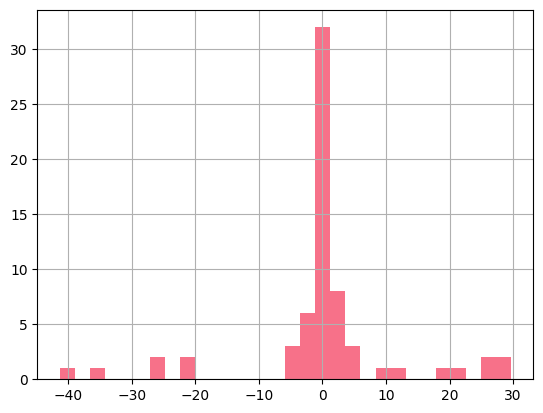

In [18]:
df_comparison['pct_diff_mean'].hist(bins=30)

<Axes: >

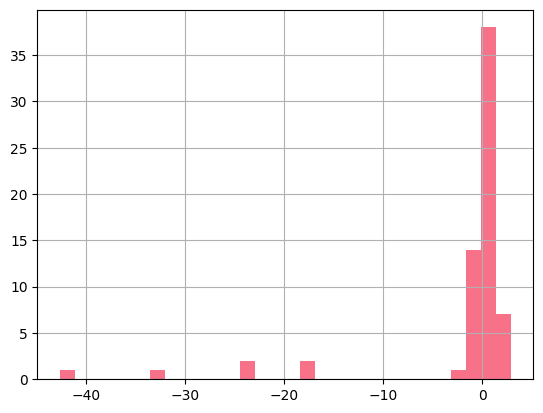

In [19]:
df_comparison['pct_diff_median'].hist(bins=30)

# Compare between Multi vs. Uni

In [20]:
# Compare multi vs uni for each model
# Focus on datasets where num_variates > 1 (only meaningful for multivariate comparison)
multi_uni_comparison = []

for model in ['Chronos2', 'Moirai', 'ToTo']:
    # Get data for both variates
    variate_multi = variate_mapping.get('multivariate', 'multivariate')
    variate_uni = variate_mapping.get('univariate', 'univariate')
    
    multi_data = df_valid[
        (df_valid['model_base'] == model) & 
        (df_valid['variate'] == variate_multi) &
        (df_valid['num_variates'] > 1)  # Filter for multi-variate datasets
    ]
    
    uni_data = df_valid[
        (df_valid['model_base'] == model) & 
        (df_valid['variate'] == variate_uni) &
        (df_valid['num_variates'] > 1)  # Filter for multi-variate datasets
    ]
    
    # Find common datasets between multi and uni
    common_datasets = set(multi_data['dataset'].unique()).intersection(set(uni_data['dataset'].unique()))
    
    if len(common_datasets) == 0:
        print(f"Warning: No common datasets between multi and uni for {model}")
        continue
    
    # Filter to common datasets
    multi_common = multi_data[multi_data['dataset'].isin(common_datasets)]
    uni_common = uni_data[uni_data['dataset'].isin(common_datasets)]
    
    print(f"\n{model}: {len(common_datasets)} common datasets (num_variates > 1) between multi and uni")
    
    # For each metric, compare multi vs uni
    for metric in metric_cols:
        # Merge on dataset to align values
        merged = multi_common[['dataset', metric]].merge(
            uni_common[['dataset', metric]],
            on='dataset',
            suffixes=('_multi', '_uni')
        )
        
        if len(merged) > 0:
            multi_values = merged[f'{metric}_multi'].values
            uni_values = merged[f'{metric}_uni'].values
            
            # Calculate differences
            diff = multi_values - uni_values
            pct_diff = (multi_values - uni_values) / uni_values * 100
            
            # Calculate win rate (where multi is better - lower is better for most metrics)
            multi_wins = (multi_values < uni_values).sum()
            uni_wins = (uni_values < multi_values).sum()
            ties = (multi_values == uni_values).sum()
            
            multi_uni_comparison.append({
                'model': model,
                'metric': metric,
                'n_datasets': len(merged),
                'multi_mean': multi_values.mean(),
                'multi_median': np.median(multi_values),
                'multi_std': multi_values.std(),
                'uni_mean': uni_values.mean(),
                'uni_median': np.median(uni_values),
                'uni_std': uni_values.std(),
                'diff_mean': diff.mean(),
                'diff_median': np.median(diff),
                'diff_std': diff.std(),
                'pct_diff_mean': pct_diff.mean(),
                'pct_diff_median': np.median(pct_diff),
                'pct_diff_std': pct_diff.std(),
                'multi_wins': multi_wins,
                'uni_wins': uni_wins,
                'ties': ties,
                'multi_win_rate': multi_wins / len(merged) * 100,
            })

df_multi_uni = pd.DataFrame(multi_uni_comparison)

print("\n" + "="*100)
print("MULTI vs UNI COMPARISON (num_variates > 1)")
print("="*100)

for model in ['Chronos2', 'Moirai', 'ToTo']:
    subset = df_multi_uni[df_multi_uni['model'] == model]
    
    if len(subset) > 0:
        print(f"\n{'='*100}")
        print(f"MODEL: {model}")
        print(f"{'='*100}")
        print(f"{'Metric':<30} {'N':<6} {'Multi Mean':<12} {'Uni Mean':<12} {'Diff%':<10} {'Multi Win%':<10}")
        print("-" * 100)
        
        for _, row in subset.iterrows():
            print(f"{row['metric']:<30} {row['n_datasets']:<6} {row['multi_mean']:>11.3f} {row['uni_mean']:>11.3f} "
                  f"{row['pct_diff_median']:>9.2f} {row['multi_win_rate']:>9.1f}")

df_multi_uni.head()



Chronos2: 16 common datasets (num_variates > 1) between multi and uni

Moirai: 22 common datasets (num_variates > 1) between multi and uni

ToTo: 8 common datasets (num_variates > 1) between multi and uni

MULTI vs UNI COMPARISON (num_variates > 1)

MODEL: Chronos2
Metric                         N      Multi Mean   Uni Mean     Diff%      Multi Win%
----------------------------------------------------------------------------------------------------
eval_metrics/MSE[mean]         16     2195936.333 2291251.491     -3.73      56.2
eval_metrics/ND[0.5]           16           0.337       0.345     -2.42      62.5
eval_metrics/MASE[0.5]         16           1.254       1.297     -2.38      62.5
eval_metrics/NRMSE[mean]       16           1.357       1.365     -1.90      56.2
eval_metrics/MAE[0.5]          16         364.181     395.681     -2.42      62.5
eval_metrics/RMSE[mean]        16         998.240    1028.578     -1.90      56.2
eval_metrics/MAPE[0.5]         16           1.101     

,model,metric,n_datasets,multi_mean,multi_median,multi_std,uni_mean,uni_median,uni_std,diff_mean,diff_median,diff_std,pct_diff_mean,pct_diff_median,pct_diff_std,multi_wins,uni_wins,ties,multi_win_rate
0,Chronos2,eval_metrics/MSE[mean],16,2.195936e+06,156994.766954,2.917549e+06,2.291251e+06,169117.156838,2.954388e+06,-95315.157749,-1.090151,261831.468787,-6.623827,-3.730034,11.212680,9,7,0,56.25
1,Chronos2,eval_metrics/ND[0.5],16,3.368062e-01,0.161883,2.970567e-01,3.446344e-01,0.176352,2.940210e-01,-0.007828,-0.002430,0.016218,-3.898947,-2.424410,5.834723,10,6,0,62.50
2,Chronos2,eval_metrics/MASE[0.5],16,1.253660e+00,0.918837,1.223477e+00,1.296588e+00,0.918829,1.218498e+00,-0.042928,-0.012017,0.072641,-3.852336,-2.377258,5.700311,10,6,0,62.50
3,Chronos2,eval_metrics/NRMSE[mean],16,1.356591e+00,0.236937,1.718449e+00,1.365445e+00,0.251254,1.712733e+00,-0.008854,-0.002501,0.022149,-3.565499,-1.901161,6.164770,9,7,0,56.25
4,Chronos2,eval_metrics/MAE[0.5],16,3.641807e+02,231.579789,4.995721e+02,3.956812e+02,231.728406,5.657172e+02,-31.500470,-0.185987,79.463949,-3.898947,-2.424410,5.834723,10,6,0,62.50


### Visualizations: Multi vs Uni

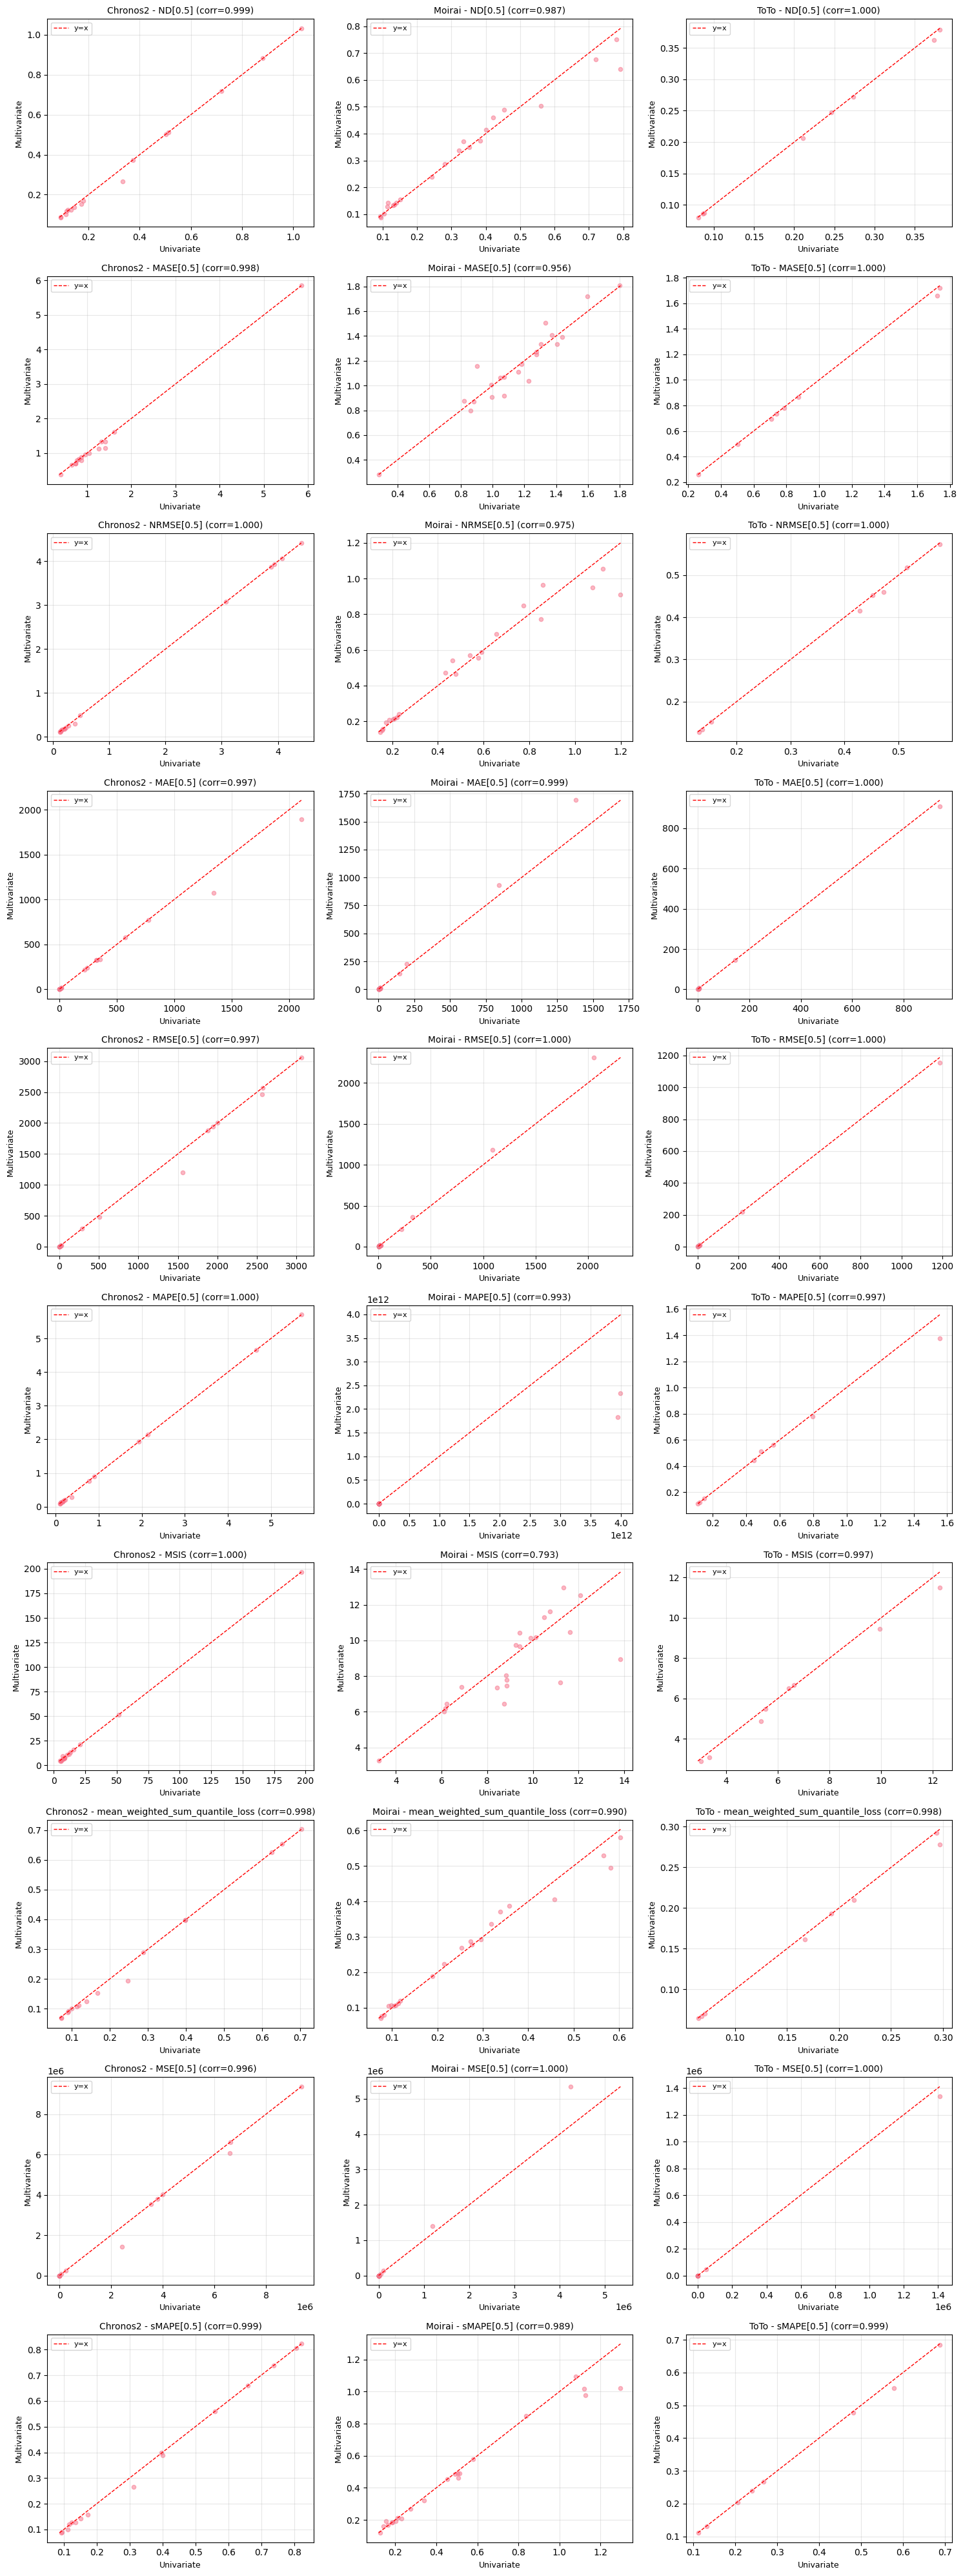

Scatter plots saved to: results_shared/pipeline_result/multi_vs_uni_scatter.png


In [26]:
# Create visualizations for multi vs uni comparison (num_variates > 1)

# 1. Scatter plots: Multi vs Uni for each metric
# Filter out MSE[mean] since it repeats MSE[0.5]
metrics_to_plot = [m for m in metric_cols if m != 'eval_metrics/MSE[mean]']
n_metrics = len(metrics_to_plot)
n_models = 3

fig, axes = plt.subplots(n_metrics, n_models, figsize=(15, 4*(n_metrics)))
if n_metrics == 1:
    axes = axes.reshape(1, -1)

models = ['Chronos2', 'Moirai', 'ToTo']

for i, metric in enumerate(metrics_to_plot):
    for j, model in enumerate(models):
        ax = axes[i, j] if n_metrics > 1 else axes[j]
        
        # Get data for this model and metric
        variate_multi = variate_mapping.get('multivariate', 'multivariate')
        variate_uni = variate_mapping.get('univariate', 'univariate')
        
        multi_data = df_valid[
            (df_valid['model_base'] == model) & 
            (df_valid['variate'] == variate_multi) &
            (df_valid['num_variates'] > 1)  # Filter for multi-variate datasets
        ]
        
        uni_data = df_valid[
            (df_valid['model_base'] == model) & 
            (df_valid['variate'] == variate_uni) &
            (df_valid['num_variates'] > 1)  # Filter for multi-variate datasets
        ]
        
        # Find common datasets
        merged = multi_data[['dataset', metric]].merge(
            uni_data[['dataset', metric]],
            on='dataset',
            suffixes=('_multi', '_uni')
        )
        
        if len(merged) > 0:
            x = merged[f'{metric}_uni'].values
            y = merged[f'{metric}_multi'].values
            
            # Scatter plot
            ax.scatter(x, y, alpha=0.5, s=20)
            
            # Add diagonal line (y=x)
            min_val = min(x.min(), y.min())
            max_val = max(x.max(), y.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1, label='y=x')
            
            # Calculate correlation
            corr = np.corrcoef(x, y)[0, 1]
            
            # Add title and labels
            ax.set_title(f'{model} - {metric.replace("eval_metrics/", "").replace("[mean]", "[0.5]")} (corr={corr:.3f})', fontsize=10)
            ax.set_xlabel('Univariate', fontsize=9)
            ax.set_ylabel('Multivariate', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{model} - {metric.replace("eval_metrics/", "").replace("[mean]", "[0.5]")}', fontsize=10)

plt.tight_layout()
# plt.savefig('../../results_shared/pipeline_result/multi_vs_uni_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Scatter plots saved to: results_shared/pipeline_result/multi_vs_uni_scatter.png")


In [22]:
# Summary statistics table
print("\n" + "="*100)
print("SUMMARY: Multi vs Uni Similarity (num_variates > 1)")
print("="*100)
print(f"{'Model':<15} {'Metric':<30} {'Corr':<10} {'Avg |Diff%|':<15} {'Multi Win%':<12}")
print("-" * 100)

for model in models:
    subset = df_multi_uni[df_multi_uni['model'] == model]
    
    if len(subset) > 0:
        for _, row in subset.iterrows():
            # Calculate correlation between multi and uni
            variate_multi = variate_mapping.get('multivariate', 'multivariate')
            variate_uni = variate_mapping.get('univariate', 'univariate')
            
            multi_data = df_valid[
                (df_valid['model_base'] == model) & 
                (df_valid['variate'] == variate_multi) &
                (df_valid['num_variates'] > 1)  # Filter for multi-variate datasets
            ]
            
            uni_data = df_valid[
                (df_valid['model_base'] == model) & 
                (df_valid['variate'] == variate_uni) &
                (df_valid['num_variates'] > 1)  # Filter for multi-variate datasets
            ]
            
            merged = multi_data[['dataset', row['metric']]].merge(
                uni_data[['dataset', row['metric']]],
                on='dataset',
                suffixes=('_multi', '_uni')
            )
            
            if len(merged) > 0:
                corr = np.corrcoef(
                    merged[f"{row['metric']}_multi"].values,
                    merged[f"{row['metric']}_uni"].values
                )[0, 1]
            else:
                corr = np.nan
            
            avg_abs_diff = abs(row['pct_diff_median'])
            
            print(f"{model:<15} {row['metric']:<30} {corr:>9.3f} {avg_abs_diff:>14.2f} {row['multi_win_rate']:>11.1f}")

# Overall summary across all metrics and models
print("\n" + "="*100)
print("OVERALL SUMMARY")
print("="*100)
print(f"Average absolute % difference (median across all): {df_multi_uni['pct_diff_median'].abs().mean():.2f}%")
print(f"Average correlation across all: {df_multi_uni.apply(lambda x: x['multi_std']/x['uni_std'] if x['uni_std'] > 0 else np.nan, axis=1).mean():.3f}")
print(f"\nConclusion: Multi and uni modes produce {'very similar' if df_multi_uni['pct_diff_median'].abs().mean() < 5 else 'similar' if df_multi_uni['pct_diff_median'].abs().mean() < 10 else 'somewhat different'} results")
print(f"  (Average difference of {df_multi_uni['pct_diff_median'].abs().mean():.2f}% across all metrics and models)")
print(f"  Note: Analysis restricted to datasets with num_variates > 1")



SUMMARY: Multi vs Uni Similarity (num_variates > 1)
Model           Metric                         Corr       Avg |Diff%|     Multi Win%  
----------------------------------------------------------------------------------------------------
Chronos2        eval_metrics/MSE[0.5]              0.996           3.73        56.2
Chronos2        eval_metrics/MASE[0.5]             0.998           2.38        62.5
Chronos2        eval_metrics/MSE[mean]             0.996           3.73        56.2
Chronos2        eval_metrics/ND[0.5]               0.999           2.42        62.5
Chronos2        eval_metrics/NRMSE[mean]           1.000           1.90        56.2
Chronos2        eval_metrics/MSIS                  1.000           0.96        62.5
Chronos2        eval_metrics/RMSE[mean]            0.997           1.90        56.2
Chronos2        eval_metrics/MAPE[0.5]             1.000           2.04        75.0
Chronos2        eval_metrics/sMAPE[0.5]            0.999           1.56        62.5
Chr

In [ ]:
df_multi_uni.head(1)

,model,metric,n_datasets,multi_mean,multi_median,multi_std,uni_mean,uni_median,uni_std,diff_mean,diff_median,diff_std,pct_diff_mean,pct_diff_median,pct_diff_std,multi_wins,uni_wins,ties,multi_win_rate
0,Chronos2,eval_metrics/MSE[0.5],16,2.195936e+06,156994.766954,2.917549e+06,2.291251e+06,169117.156838,2.954388e+06,-95315.157749,-1.090151,261831.468787,-6.623827,-3.730034,11.21268,9,7,0,56.25


In [31]:
df_multi_uni.groupby(['model', 'metric']).agg({
    'multi_win_rate': 'mean'
}).reset_index().to_csv('../../results_shared/pipeline_result/multi_uni_win_rates.csv', index=False)

In [23]:
df_valid.query("num_variates > 1").to_csv("../../results_shared/pipeline_result/validated_experiment_results.csv", index=False)